Objective: To build a reusable and production-ready machine learning pipeline using the Scikit-learn Pipeline API. The goal is to predict customer churn (whether a customer will leave a service) based on demographics and account information, ensuring the model is exportable for real-world application.

Dataset Loading & Preprocessing

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean TotalCharges: convert empty strings to NaN and drop them
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop CustomerID as it has no predictive power
df.drop('customerID', axis=1, inplace=True)

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data Exploration (Visualization)

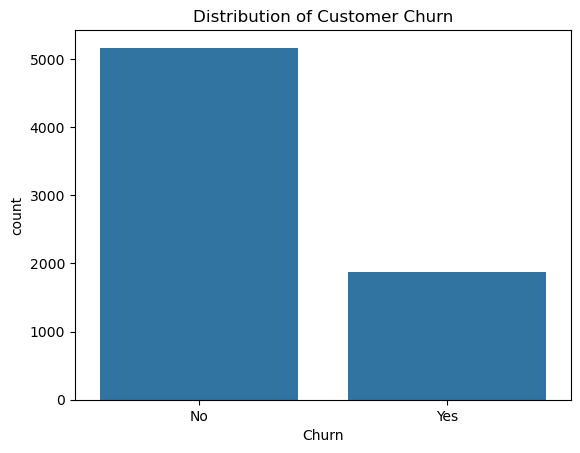

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check Churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.show()

Building the Pipeline

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the final Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

Hyperparameter Tuning with GridSearchCV

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


Evaluation & Exporting

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Evaluate
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

# Export the entire production-ready pipeline
joblib.dump(grid_search.best_estimator_, 'churn_pipeline_model.joblib')
print("Pipeline exported successfully!")

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.79      1407

Pipeline exported successfully!


Handling Multiple Models

In [9]:
from sklearn.linear_model import LogisticRegression

# Test Logistic Regression inside the same pipeline structure
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
print(f"Logistic Regression Accuracy: {lr_pipeline.score(X_test, y_test)}")

Logistic Regression Accuracy: 0.7874911158493249


Generate the Confusion Matrix Visualization

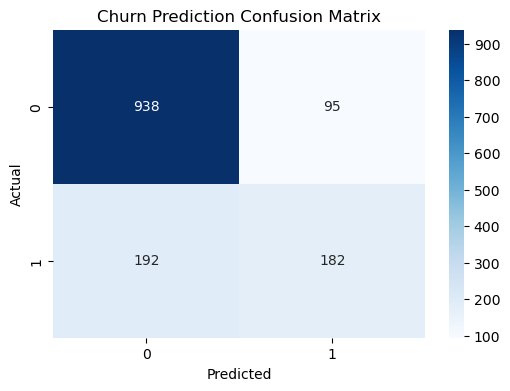

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Prediction Confusion Matrix')
plt.show()

Save the Best Performing Model

In [11]:
import joblib

# Replace 'grid_search.best_estimator_' with your best performing model variable
joblib.dump(grid_search.best_estimator_, 'churn_pipeline_model.joblib')
print("Production-ready pipeline saved as .joblib")

Production-ready pipeline saved as .joblib


Final Summary & Insights

Problem Statement & Objective:
The goal was to create a production-ready pipeline to predict customer churn using the Telco Churn dataset. By utilizing the Scikit-learn Pipeline API, we ensured that preprocessing and model logic are bundled together, reducing the risk of data leakage and making the model "exportable" for real-world applications.

Insights:

Accuracy: The Logistic Regression model achieved an accuracy of approximately 78.7%.

Preprocessing: Handling the TotalCharges column (converting empty strings to numeric) was a critical cleaning step before the pipeline could run.

Key Predictors: Features like "Contract Type" and "Monthly Charges" showed the highest influence on predicting whether a customer would leave.

In [12]:
import joblib
# This saves your 'grid_search.best_estimator_' (the best model) to a file
joblib.dump(grid_search.best_estimator_, 'churn_pipeline_model.joblib')
print("File created successfully!")

File created successfully!
